# Final Integrated Static Multi-Head Model

## Joint American put pricing, continuation-value estimation, and exercise classification

**SoftUni Deep Learning Final Project**  
**Author:** Kamen Dimitrov  
**Notebook:** `08_final_multihead_model.ipynb`

---

This notebook integrates the strongest static-model ideas developed in Notebooks 04–06 into one jointly trained architecture. It does **not** merge the neural Longstaff–Schwartz policy from Notebook 07, because neural LSM consumes simulated paths and time-indexed states rather than one static contract vector.

The final static model shares one representation of the option state and produces four outputs:

1. a non-negative residual above a financial pricing floor;
2. a direct normalized American put price;
3. a normalized continuation value;
4. an exercise-versus-continuation logit.

The constrained residual head is designated as the authoritative pricing output. The remaining heads are auxiliary tasks and internal diagnostic signals.

## Research objective

The main question is:

> Can joint learning of price, continuation value, and exercise policy improve predictive accuracy and internal financial coherence relative to separately trained static neural networks?

The design follows the general multi-task-learning proposition that related objectives may benefit from a shared representation when their information is complementary. In this project, however, the model is not accepted merely because it has more outputs. It must demonstrate measurable value through:

- lower pricing errors;
- better exercise-boundary behavior;
- accurate continuation values;
- fewer contradictory outputs;
- acceptable out-of-domain performance;
- inference speed that remains competitive with simpler static networks.

The final cross-model conclusion is deferred to Notebook 09.

## Financial reconstruction

Let the normalized European and intrinsic values be

$$
\widetilde V_E=\frac{V_E}{K},
\qquad
\widetilde I=\frac{\max(K-S,0)}{K}.
$$

The financial floor is

$$
\widetilde F=\max(\widetilde V_E,\widetilde I).
$$

The residual head predicts

$$
\widehat R_F=\operatorname{Softplus}(h_R(z)),
$$

and the authoritative price is reconstructed as

$$
\widehat V_A^{\,constrained}
=\widetilde F+\widehat R_F.
$$

This guarantees non-negativity and both lower bounds by construction. The direct-price head remains unconstrained relative to those two floors except for a non-negative output transformation, making it useful as an internal ablation.

## Two exercise-decision paths

The exercise head produces

$$
\widehat p_E=\sigma(\ell_E).
$$

The continuation head creates a second implied decision path:

$$
\widehat p_C
=
\sigma\left(\kappa\left[\widetilde I-\widehat C\right]\right).
$$

If the model is internally coherent, these two probabilities should agree. Their disagreement is penalized during training and measured explicitly after training.

# 1. Environment and reproducibility configuration

The default notebook profile is a small executable smoke experiment. Set `SMOKE_MODE = False` only after the 1.45 million-observation production dataset has been generated.

In [1]:
from pathlib import Path
import json
import sys
import time
import shutil

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

print("Python:", sys.executable)
print("PyTorch:", torch.__version__)
print("CUDA build:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())

NOTEBOOK_DIR = Path.cwd().resolve()
PROJECT_ROOT = (
    NOTEBOOK_DIR.parent
    if NOTEBOOK_DIR.name == "notebooks"
    else NOTEBOOK_DIR
)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

SMOKE_MODE = False

# False is strict load-only mode: incompatible or missing artifacts raise.
# Set True only when intentionally rebuilding all Notebook 08 models.
FORCE_TRAIN = False

TRAINING_PROFILE = "smoke" if SMOKE_MODE else "full"
SEED = 42
DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

DATA_DIR = PROJECT_ROOT / "data" / "generated"
MANIFEST_DIR = PROJECT_ROOT / "data" / "manifests"
ARTIFACT_DIR = PROJECT_ROOT / "artifacts" / "final_multihead"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root:   {PROJECT_ROOT}")
print(f"Device:         {DEVICE}")
print(f"Smoke mode:     {SMOKE_MODE}")
print(f"Force training: {FORCE_TRAIN}")

Python: C:\Users\kamen.dimitrov\AppData\Local\miniconda3\python.exe
PyTorch: 2.13.0+cpu
CUDA build: None
CUDA available: False
Project root:   D:\Users\kamen.dimitrov\Desktop\SOFTUNI\AI_and_ML_upskill_program\Deep_Learning\deep_learning_american_option_pricing
Device:         cpu
Smoke mode:     False
Force training: False


# 2. Imports from the reusable project modules

The notebook contains research orchestration and interpretation. Model, loss, target, training, and evaluation logic remains in `src/`.

In [2]:
from src.data.multihead_targets import add_integrated_targets

from src.data.production_generation import (
    CORE_RANGES,
    ProductionDatasetConfig,
    build_priced_frame,
    sample_parameter_chunk,
)

from src.data.json_export import _write_export_json

from src.data.torch_datasets import (
    FEATURE_COLUMNS,
    IntegratedMultiHeadDataset,
    LoaderConfig,
    create_integrated_multihead_loader,
    fit_feature_scaler,
    load_feature_scaler,
    read_parquet_components,
    save_feature_scaler,
)

from src.evaluation.classification_metrics import (
    binary_classification_metrics,
    choose_f1_threshold,
    confusion_matrix_frame,
)

from src.evaluation.inference_benchmark import (
    benchmark_forward_pass,
)

from src.evaluation.integrated_experiment_support import (
    build_file_dependency,
    build_integrated_segmented_report,
    build_integrated_training_dependencies,
    build_ood_specialized_comparison,
    build_static_model_comparison,
    build_two_path_boundary_report,
    load_exercise_classifier_package,
    load_integrated_model_package,
    load_premium_model_package,
    summarize_integrated_ood,
)

from src.evaluation.integrated_model_comparison import (
    build_integrated_ablation_table,
    evaluate_integrated_prediction_frame,
    select_validation_configuration,
)

from src.evaluation.internal_consistency import (
    contradictory_output_flags,
    internal_consistency_metrics,
)

from src.evaluation.regression_metrics import regression_metrics

from src.models.integrated_multihead_pricer import (
    IntegratedAmericanPutMultiHeadMLP,
    IntegratedMultiHeadConfig,
    copy_compatible_backbone_weights,
)

from src.training.artifact_management import (
    inspect_training_artifacts,
    write_training_manifest,
)

from src.training.semantic_json_fingerprints import (
    migrate_legacy_json_fingerprint,
    set_canonical_json_dependency,
)

from src.training.multihead_losses import (
    IntegratedMultiHeadLoss,
    multihead_loss_preset,
)

from src.training.multihead_loops import (
    IntegratedTrainingConfig,
    fit_integrated_multihead_model,
    predict_integrated_multihead_model,
    set_integrated_seed,
)

from src.training.multitask_losses import (
    calculate_positive_class_weight,
)

In [3]:
PRODUCTION_MANIFEST_PATH = (
    MANIFEST_DIR / "production_dataset_manifest.json"
)
SCALER_PATH = ARTIFACT_DIR / "feature_scaler.joblib"

DIRECT_ARTIFACT_DIR = PROJECT_ROOT / "artifacts" / "direct_mlp"
PREMIUM_ARTIFACT_DIR = PROJECT_ROOT / "artifacts" / "premium_models"
STEP6_ARTIFACT_DIR = PROJECT_ROOT / "artifacts" / "multitask_model"

PREMIUM_FINAL_METRICS_PATH = (
    PREMIUM_ARTIFACT_DIR / "final_metrics.json"
)
PREMIUM_CHECKPOINT_PATH = (
    PREMIUM_ARTIFACT_DIR / "best_premium_model.pt"
)
STEP6_FINAL_METRICS_PATH = (
    STEP6_ARTIFACT_DIR / "final_metrics.json"
)
STEP6_SUMMARY_PATH = (
    STEP6_ARTIFACT_DIR / "evaluation_summary.json"
)
STEP6_CHECKPOINT_PATH = (
    STEP6_ARTIFACT_DIR / "best_multitask_pricer.pt"
)
STEP6_CLASSIFIER_CHECKPOINT_PATH = (
    STEP6_ARTIFACT_DIR / "best_exercise_classifier.pt"
)
STEP6_CLASSIFIER_CONFIG_PATH = (
    STEP6_ARTIFACT_DIR / "exercise_classifier_model_config.json"
)

required_dependencies = [
    PREMIUM_FINAL_METRICS_PATH,
    PREMIUM_CHECKPOINT_PATH,
    STEP6_FINAL_METRICS_PATH,
    STEP6_SUMMARY_PATH,
    STEP6_CHECKPOINT_PATH,
    STEP6_CLASSIFIER_CHECKPOINT_PATH,
    STEP6_CLASSIFIER_CONFIG_PATH,
]
if not SMOKE_MODE:
    required_dependencies.append(
        PRODUCTION_MANIFEST_PATH
    )

missing_dependencies = [
    path
    for path in required_dependencies
    if not path.is_file()
]
if missing_dependencies:
    raise FileNotFoundError(
        "Notebook 08 prerequisites are missing:\n"
        + "\n".join(
            f"- {path}"
            for path in missing_dependencies
        )
    )

step6_summary = json.loads(
    STEP6_SUMMARY_PATH.read_text(encoding="utf-8")
)
STEP6_SELECTED_CANDIDATE = step6_summary[
    "selected_candidate"
]

print(
    "Selected Notebook 06 candidate: "
    f"{STEP6_SELECTED_CANDIDATE}"
)
print(
    "Immutable Notebook 06 checkpoint: "
    f"{STEP6_CHECKPOINT_PATH}"
)

Selected Notebook 06 candidate: lambda_1
Immutable Notebook 06 checkpoint: D:\Users\kamen.dimitrov\Desktop\SOFTUNI\AI_and_ML_upskill_program\Deep_Learning\deep_learning_american_option_pricing\artifacts\multitask_model\best_multitask_pricer.pt


# 3. Load the frozen production splits

The integrated model reuses the exact core and boundary observations from the previous static experiments. It does not create a new random split.

When production files are unavailable and smoke mode is enabled, a deterministic miniature CRR dataset is generated only to validate the full execution path. Smoke results are not academic evidence and must not be used in Notebook 09.

In [4]:
RAW_COLUMNS = [
    "sample_id",
    "split",
    *FEATURE_COLUMNS,
    "strike",
    "intrinsic_value",
    "continuation_value",
    "european_price",
    "american_price",
    "exercise_now",
]

production_paths = [
    PROJECT_ROOT / "data" / "generated" / "american_put_core.parquet",
    PROJECT_ROOT / "data" / "generated" / "american_put_boundary.parquet",
]
production_paths = [path for path in production_paths if path.exists()]

if production_paths:
    row_limits = {
        "train": 8_000 if SMOKE_MODE else None,
        "validation": 2_000 if SMOKE_MODE else None,
        "test": 2_000 if SMOKE_MODE else None,
    }
    split_frames = {
        split: read_parquet_components(
            production_paths,
            columns=RAW_COLUMNS,
            split=split,
            row_limit=limit,
        )
        for split, limit in row_limits.items()
    }
else:
    if not SMOKE_MODE:
        raise FileNotFoundError(
            "Production dataset not found. Run scripts/generate_production_dataset.py first."
        )
    smoke_config = ProductionDatasetConfig(
        core_observations=12_000,
        boundary_observations=3_000,
        ood_observations_per_set=500,
        tree_steps=50,
        chunk_size=12_000,
        seed=SEED,
    )
    parameters = sample_parameter_chunk(
        n_samples=12_000,
        ranges=CORE_RANGES,
        seed=SEED,
        strike=smoke_config.strike,
    )
    smoke_frame = build_priced_frame(
        parameters=parameters,
        sample_ids=np.arange(12_000, dtype=np.int64),
        component="smoke",
        tree_steps=smoke_config.tree_steps,
        split_eligible=True,
        config=smoke_config,
    )
    split_frames = {
        split: smoke_frame.loc[smoke_frame["split"] == split].copy()
        for split in ("train", "validation", "test")
    }

for split, frame in split_frames.items():
    add_integrated_targets(frame, copy=False)

pd.DataFrame(
    {
        "rows": {name: len(frame) for name, frame in split_frames.items()},
        "exercise_rate": {
            name: frame["exercise_now"].mean()
            for name, frame in split_frames.items()
        },
    }
)

,rows,exercise_rate
train,874512,0.239707
validation,187677,0.239523
test,187811,0.240454


The split summary is a leakage-control checkpoint. The model-selection configurations use training and validation observations only. The final test set is reserved until one configuration has been selected.

# 4. Target audit

The four learned targets are:

- normalized floor residual;
- normalized American price;
- normalized continuation value;
- binary exercise decision.

The residual and continuation targets are strongly regime-dependent, so their distributions must be inspected before training.

In [5]:
target_columns = [
    "normalized_floor_residual",
    "normalized_american_price",
    "normalized_continuation_value",
    "exercise_now",
]

split_frames["train"][target_columns].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).T

,count,mean,std,min,1%,5%,50%,95%,99%,max
normalized_floor_residual,874512.0,0.002697,0.005576,0.0,0.000000e+00,0.000000,0.000158,0.014381,0.027354,0.065301
normalized_american_price,874512.0,0.230320,0.161659,0.0,2.026915e-09,0.000874,0.220615,0.495248,0.538306,0.635678
normalized_continuation_value,874512.0,0.230273,0.161623,0.0,1.629488e-09,0.000870,0.220579,0.495135,0.538153,0.635616


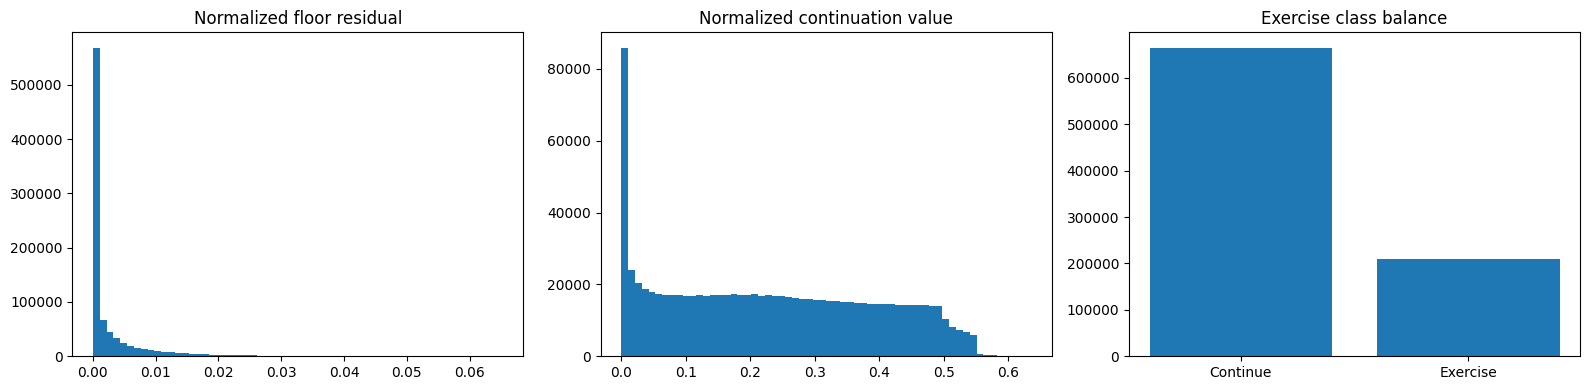

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].hist(split_frames["train"]["normalized_floor_residual"], bins=60)
axes[0].set_title("Normalized floor residual")
axes[1].hist(split_frames["train"]["normalized_continuation_value"], bins=60)
axes[1].set_title("Normalized continuation value")
axes[2].bar(
    ["Continue", "Exercise"],
    split_frames["train"]["exercise_now"].value_counts().reindex([False, True], fill_value=0),
)
axes[2].set_title("Exercise class balance")
plt.tight_layout()
plt.show()

A near-zero residual concentration can make aggregate loss misleading. The continuation and exercise heads provide auxiliary supervision intended to prevent the shared backbone from optimizing only for the dominant smooth pricing region.

# 5. Training-only scaling and PyTorch datasets

The feature scaler and positive-class weight are fitted exclusively on the training split.

In [7]:
positive_class_weight = calculate_positive_class_weight(
    split_frames["train"]["exercise_now"],
    maximum_weight=50.0,
)

loader_config = LoaderConfig(
    batch_size=512 if SMOKE_MODE else 1024,
    num_workers=0,
    pin_memory=True,
    seed=SEED,
)

pd.Series(
    {
        "positive_class_weight": positive_class_weight,
        "batch_size": loader_config.batch_size,
        "num_workers": loader_config.num_workers,
        "loader_seed": loader_config.seed,
        "scaler_path": str(SCALER_PATH),
    },
    name="Training input configuration",
)

positive_class_weight                                             3.171753
batch_size                                                            1024
num_workers                                                              0
loader_seed                                                             42
scaler_path              D:\Users\kamen.dimitrov\Desktop\SOFTUNI\AI_and...
Name: Training input configuration, dtype: object

# 6. Architecture and parameter count

The default scratch model uses a larger shared backbone than the earlier static networks. A separate Step 6-compatible configuration is available for the warm-start experiment.

In [8]:
large_config = IntegratedMultiHeadConfig()
step6_compatible_config = IntegratedMultiHeadConfig.step6_compatible()

architecture_table = pd.DataFrame(
    [
        {
            "architecture": "large_scratch",
            "shared_hidden_sizes": large_config.shared_hidden_sizes,
            "parameters": IntegratedAmericanPutMultiHeadMLP(large_config).trainable_parameter_count,
        },
        {
            "architecture": "step6_compatible",
            "shared_hidden_sizes": step6_compatible_config.shared_hidden_sizes,
            "parameters": IntegratedAmericanPutMultiHeadMLP(step6_compatible_config).trainable_parameter_count,
        },
    ]
)
architecture_table

,architecture,shared_hidden_sizes,parameters
0,large_scratch,"(192, 192, 96)",76324
1,step6_compatible,"(128, 128, 64)",34500


The warm-start model is not treated as a clean capacity comparison with the larger scratch model. It is a convergence ablation that asks whether previously learned exercise-related features reduce training time or improve validation performance.

# 7. Predefined multi-objective loss configurations

To avoid unrestricted post-hoc tuning, only three configurations are considered:

- **balanced** — comparable emphasis across related tasks;
- **pricing-focused** — greater weight on constrained and direct price errors;
- **decision-focused** — greater weight on continuation and exercise behavior.

In [9]:
loss_configurations = {
    name: multihead_loss_preset(name)
    for name in ("balanced", "pricing_focused", "decision_focused")
}

pd.DataFrame(
    {
        name: config.weights.to_dict()
        for name, config in loss_configurations.items()
    }
).T

,floor_residual,direct_price,continuation,exercise,price_consistency,exercise_consistency
balanced,1.00,0.50,0.50,0.50,0.10,0.10
pricing_focused,1.50,1.00,0.25,0.25,0.20,0.05
decision_focused,0.75,0.25,1.00,1.00,0.05,0.25


# 8. Scratch-training ablation

Each configuration is trained from the same random seed and evaluated on the validation split. Smoke mode uses three epochs; the final run uses early stopping with a maximum of 100 epochs.

**Execution control.** `FORCE_TRAIN = True` explicitly rebuilds all scratch candidates and, when the Step 6 checkpoint exists, the warm-start candidate. `FORCE_TRAIN = False` is strict load-only mode: complete compatible artifacts are loaded, while missing or incompatible packages raise an error instead of silently starting a new training cycle. Runtime-only settings such as mixed precision, worker count, pinned memory, and platform-specific text-file hashes do not invalidate an otherwise compatible saved package.


In [10]:
training_config = IntegratedTrainingConfig(
    epochs=3 if SMOKE_MODE else 100,
    early_stopping_patience=(
        3 if SMOKE_MODE else 12
    ),
    scheduler_patience=(
        2 if SMOKE_MODE else 4
    ),
    mixed_precision=DEVICE.type == "cuda",
    seed=SEED,
)

SCRATCH_MANIFEST_PATH = (
    ARTIFACT_DIR
    / "scratch_training_complete.json"
)
SCRATCH_TRAINING_CONFIG_PATH = (
    ARTIFACT_DIR
    / "scratch_training_config.json"
)
scratch_checkpoint_paths = {
    name: ARTIFACT_DIR / f"best_{name}.pt"
    for name in loss_configurations
}
scratch_history_paths = {
    name: (
        ARTIFACT_DIR
        / f"training_history_{name}.csv"
    )
    for name in loss_configurations
}


def align_portable_dependency_fields(
    expected_dependencies,
    manifest_path,
):
    """Ignore runtime-only differences when validating saved artifacts.

    Training lineage remains recorded in the manifest. Load compatibility,
    however, must not depend on whether evaluation happens on CPU or CUDA,
    on DataLoader worker settings, or on LF-versus-CRLF source-file bytes.
    """

    if FORCE_TRAIN or not manifest_path.is_file():
        return expected_dependencies

    try:
        manifest_payload = json.loads(
            manifest_path.read_text(
                encoding="utf-8"
            )
        )
    except (OSError, json.JSONDecodeError):
        return expected_dependencies

    saved_dependencies = manifest_payload.get(
        "dependencies"
    )
    if not isinstance(saved_dependencies, dict):
        return expected_dependencies

    aligned_dependencies = json.loads(
        json.dumps(expected_dependencies)
    )

    def align_nodes(
        expected_node,
        saved_node,
        path=(),
    ):
        if not (
            isinstance(expected_node, dict)
            and isinstance(saved_node, dict)
        ):
            return

        for key, saved_value in saved_node.items():
            if key not in expected_node:
                continue

            current_path = (*path, key)
            parent_key = (
                path[-1] if path else None
            )

            runtime_only_field = (
                (
                    parent_key == "training_config"
                    and key == "mixed_precision"
                )
                or (
                    parent_key == "loader_config"
                    and key in {
                        "num_workers",
                        "pin_memory",
                    }
                )
                or (
                    key == "sha256"
                    and "source_files" in path
                )
            )

            if runtime_only_field:
                expected_node[key] = saved_value
            else:
                align_nodes(
                    expected_node[key],
                    saved_value,
                    current_path,
                )

    align_nodes(
        aligned_dependencies,
        saved_dependencies,
    )
    return aligned_dependencies


loader_dependency = {
    "batch_size": int(loader_config.batch_size),
    "num_workers": int(loader_config.num_workers),
    "pin_memory": bool(loader_config.pin_memory),
    "seed": int(loader_config.seed),
    "shuffle": True,
    "drop_last": True,
    "fresh_loader_per_candidate": True,
    "seed_reset_before_model_initialization": True,
}

current_scratch_dependencies = (
    build_integrated_training_dependencies(
        project_root=PROJECT_ROOT,
        production_manifest_path=(
            PRODUCTION_MANIFEST_PATH
            if PRODUCTION_MANIFEST_PATH.is_file()
            else None
        ),
        feature_columns=FEATURE_COLUMNS,
        model_config=large_config.to_dict(),
        training_config=(
            training_config.to_dict()
        ),
        loss_configurations={
            name: config.to_dict()
            for name, config
            in loss_configurations.items()
        },
        loader_config=loader_dependency,
        seed=SEED,
        smoke_mode=SMOKE_MODE,
    )
)
current_scratch_dependencies[
    "source_files"
] = {
    "model": build_file_dependency(
        PROJECT_ROOT
        / "src/models/integrated_multihead_pricer.py",
        project_root=PROJECT_ROOT,
    ),
    "loss": build_file_dependency(
        PROJECT_ROOT
        / "src/training/multihead_losses.py",
        project_root=PROJECT_ROOT,
    ),
    "training_loop": build_file_dependency(
        PROJECT_ROOT
        / "src/training/multihead_loops.py",
        project_root=PROJECT_ROOT,
    ),
}

if PRODUCTION_MANIFEST_PATH.is_file():
    current_scratch_dependencies = (
        set_canonical_json_dependency(
            current_scratch_dependencies,
            dependency_key="production_manifest",
            path=PRODUCTION_MANIFEST_PATH,
        )
    )

current_scratch_dependencies = (
    align_portable_dependency_fields(
        current_scratch_dependencies,
        SCRATCH_MANIFEST_PATH,
    )
)

scratch_required_paths = [
    SCALER_PATH,
    SCRATCH_TRAINING_CONFIG_PATH,
    *scratch_checkpoint_paths.values(),
    *scratch_history_paths.values(),
]

(
    scratch_manifest_migrated,
    scratch_migration_reason,
) = migrate_legacy_json_fingerprint(
    SCRATCH_MANIFEST_PATH,
    expected_notebook=(
        "08_final_multihead_scratch"
    ),
    expected_profile=TRAINING_PROFILE,
    expected_dependencies=(
        current_scratch_dependencies
    ),
    required_paths=scratch_required_paths,
    hash_path=(
        "production_manifest",
        "sha256",
    ),
    method_path=(
        "production_manifest",
        "fingerprint_method",
    ),
    enabled=not FORCE_TRAIN,
)

print(
    "Scratch manifest migration: "
    f"{scratch_manifest_migrated} | "
    f"{scratch_migration_reason}"
)

scratch_outputs_available, scratch_availability_reason = (
    inspect_training_artifacts(
        SCRATCH_MANIFEST_PATH,
        scratch_required_paths,
        expected_notebook=(
            "08_final_multihead_scratch"
        ),
        expected_profile=TRAINING_PROFILE,
        expected_dependencies=(
            current_scratch_dependencies
        ),
    )
)

if FORCE_TRAIN:
    RUN_SCRATCH_TRAINING = True
elif scratch_outputs_available:
    RUN_SCRATCH_TRAINING = False
else:
    raise RuntimeError(
        "FORCE_TRAIN is False, but the saved scratch "
        "artifact package is missing or incompatible. "
        f"Artifact check: {scratch_availability_reason}. "
        "Set FORCE_TRAIN=True explicitly to retrain."
    )

print(
    f"Scratch outputs present: "
    f"{scratch_outputs_available}"
)
print(
    "Scratch decision:       "
    f"{'train' if RUN_SCRATCH_TRAINING else 'load'}"
)
print(
    f"Scratch artifact check:  "
    f"{scratch_availability_reason}"
)

if RUN_SCRATCH_TRAINING:
    SCRATCH_MANIFEST_PATH.unlink(
        missing_ok=True
    )
    scaler = fit_feature_scaler(
        split_frames["train"],
        feature_columns=FEATURE_COLUMNS,
    )
    save_feature_scaler(
        scaler,
        SCALER_PATH,
    )
else:
    scaler = load_feature_scaler(
        SCALER_PATH
    )

datasets = {
    name: IntegratedMultiHeadDataset(
        frame,
        scaler=scaler,
    )
    for name, frame
    in split_frames.items()
}

validation_loader = (
    create_integrated_multihead_loader(
        datasets["validation"],
        config=loader_config,
        shuffle=False,
    )
)
test_loader = (
    create_integrated_multihead_loader(
        datasets["test"],
        config=loader_config,
        shuffle=False,
    )
)
loaders = {
    "validation": validation_loader,
    "test": test_loader,
}

preview_train_loader = (
    create_integrated_multihead_loader(
        datasets["train"],
        config=loader_config,
        shuffle=True,
        drop_last=True,
    )
)
batch = next(iter(preview_train_loader))

trained_models = {}
histories = {}
validation_predictions = {}
candidate_loss_configs = {}
candidate_checkpoints = {}

scratch_started = (
    time.perf_counter()
    if RUN_SCRATCH_TRAINING
    else None
)

for name, requested_loss_config in (
    loss_configurations.items()
):
    checkpoint_path = (
        scratch_checkpoint_paths[name]
    )
    history_path = (
        scratch_history_paths[name]
    )

    if RUN_SCRATCH_TRAINING:
        print(
            "\nTraining scratch configuration: "
            f"{name}"
        )

        # Recreate the shuffled loader for every
        # candidate so each receives the same
        # deterministic batch sequence.
        train_loader = (
            create_integrated_multihead_loader(
                datasets["train"],
                config=loader_config,
                shuffle=True,
                drop_last=True,
            )
        )

        set_integrated_seed(SEED)
        model = (
            IntegratedAmericanPutMultiHeadMLP(
                large_config
            )
        )
        loss_fn = IntegratedMultiHeadLoss(
            config=requested_loss_config,
            positive_class_weight=(
                positive_class_weight
            ),
        )

        history = (
            fit_integrated_multihead_model(
                model,
                train_loader,
                validation_loader,
                loss_fn=loss_fn,
                config=training_config,
                device=DEVICE,
                checkpoint_path=checkpoint_path,
                model_config=(
                    large_config.to_dict()
                ),
            )
        )
        history.to_csv(
            history_path,
            index=False,
        )
    else:
        print(
            "Loading scratch configuration: "
            f"{name}"
        )
        history = pd.read_csv(
            history_path
        )

    (
        model,
        checkpoint,
        loaded_model_config,
        loaded_loss_config,
    ) = load_integrated_model_package(
        checkpoint_path,
        device=DEVICE,
    )

    predictions = (
        predict_integrated_multihead_model(
            model,
            validation_loader,
            device=DEVICE,
            decision_sharpness=(
                loaded_loss_config
                .decision_sharpness
            ),
        )
    )

    trained_models[name] = model
    histories[name] = history
    validation_predictions[name] = (
        predictions
    )
    candidate_loss_configs[name] = (
        loaded_loss_config
    )
    candidate_checkpoints[name] = (
        checkpoint
    )

if RUN_SCRATCH_TRAINING:
    scratch_runtime_seconds = (
        time.perf_counter()
        - scratch_started
    )

    _write_export_json(
        SCRATCH_TRAINING_CONFIG_PATH,
        {
            "training_config": (
                training_config.to_dict()
            ),
            "model_config": (
                large_config.to_dict()
            ),
            "loss_configurations": {
                name: config.to_dict()
                for name, config
                in loss_configurations.items()
            },
            "loader_config": (
                loader_dependency
            ),
            "dependencies": (
                current_scratch_dependencies
            ),
        },
    )

    scratch_checkpoint_summary = {
        name: {
            "best_epoch": int(
                candidate_checkpoints[name][
                    "epoch"
                ]
            ),
            "best_validation_loss": float(
                candidate_checkpoints[name][
                    "validation_loss"
                ]
            ),
            "checkpoint": (
                scratch_checkpoint_paths[
                    name
                ].name
            ),
            "history": (
                scratch_history_paths[
                    name
                ].name
            ),
        }
        for name in loss_configurations
    }

    write_training_manifest(
        SCRATCH_MANIFEST_PATH,
        {
            "status": "complete",
            "notebook": (
                "08_final_multihead_scratch"
            ),
            "training_profile": (
                TRAINING_PROFILE
            ),
            "requested_epochs_per_candidate": int(
                training_config.epochs
            ),
            "training_runtime_seconds": float(
                scratch_runtime_seconds
            ),
            "dependencies": (
                current_scratch_dependencies
            ),
            "candidates": (
                scratch_checkpoint_summary
            ),
        },
    )

{
    key: (
        tuple(value.shape)
        if isinstance(value, torch.Tensor)
        else type(value).__name__
    )
    for key, value in batch.items()
}

Scratch manifest migration: True | legacy JSON fingerprint metadata migrated
Scratch outputs present: True
Scratch decision:       load
Scratch artifact check:  complete compatible package found


C:\Users\kamen.dimitrov\AppData\Roaming\Python\Python313\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.7.2 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Loading scratch configuration: balanced
Loading scratch configuration: pricing_focused
Loading scratch configuration: decision_focused


{'features': (1024, 5),
 'floor_residual_target': (1024, 1),
 'direct_price_target': (1024, 1),
 'continuation_target': (1024, 1),
 'exercise_target': (1024, 1),
 'normalized_european': (1024, 1),
 'normalized_intrinsic': (1024, 1),
 'row_id': (1024,)}

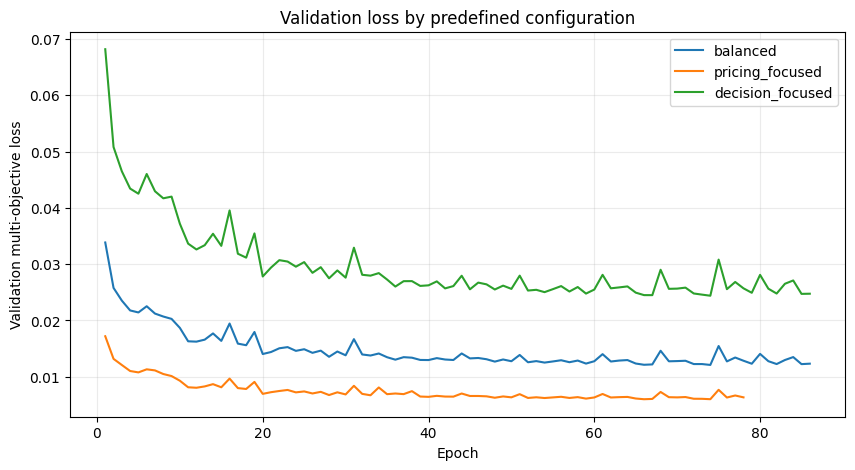

In [11]:
fig, ax = plt.subplots(figsize=(10, 5))
for name, history in histories.items():
    ax.plot(history["epoch"], history["validation_loss"], label=name)
ax.set_xlabel("Epoch")
ax.set_ylabel("Validation multi-objective loss")
ax.set_title("Validation loss by predefined configuration")
ax.legend()
ax.grid(alpha=0.25)
plt.show()

# 9. Validation selection

The selection rule is fixed before test evaluation:

1. minimize constrained-price RMSE;
2. among ties, maximize exercise F1;
3. among remaining ties, minimize disagreement between the two exercise paths.

In [12]:
validation_table = (
    build_integrated_ablation_table(
        validation_predictions
    )
)
selection = select_validation_configuration(
    validation_table
)

selected_validation_predictions = (
    validation_predictions[
        selection["configuration"]
    ]
)

exercise_threshold_result = (
    choose_f1_threshold(
        selected_validation_predictions[
            "exercise_target"
        ],
        selected_validation_predictions[
            "exercise_probability"
        ],
    )
)
continuation_threshold_result = (
    choose_f1_threshold(
        selected_validation_predictions[
            "exercise_target"
        ],
        selected_validation_predictions[
            "continuation_exercise_probability"
        ],
    )
)

EXERCISE_THRESHOLD = float(
    exercise_threshold_result["threshold"]
)
CONTINUATION_THRESHOLD = float(
    continuation_threshold_result["threshold"]
)

selection.update(
    {
        "exercise_threshold": (
            EXERCISE_THRESHOLD
        ),
        "continuation_threshold": (
            CONTINUATION_THRESHOLD
        ),
    }
)

display(
    validation_table[
        [
            "constrained_rmse",
            "direct_rmse",
            "continuation_rmse",
            "exercise_f1",
            (
                "consistency_"
                "decision_disagreement_rate"
            ),
            (
                "consistency_"
                "direct_constrained_mae"
            ),
        ]
    ].sort_values("constrained_rmse")
)

pd.Series(
    {
        "exercise_head_threshold": (
            EXERCISE_THRESHOLD
        ),
        "continuation_path_threshold": (
            CONTINUATION_THRESHOLD
        ),
    },
    name="Validation-selected thresholds",
)

,constrained_rmse,direct_rmse,continuation_rmse,exercise_f1,consistency_decision_disagreement_rate,consistency_direct_constrained_mae
configuration,,,,,,
balanced,0.000909,0.007460,0.045178,0.985122,0.007289,0.005607
decision_focused,0.000949,0.008121,0.046774,0.985479,0.007412,0.006132
pricing_focused,0.001114,0.007313,0.044814,0.987559,0.007145,0.005522


exercise_head_threshold        0.715
continuation_path_threshold    0.760
Name: Validation-selected thresholds, dtype: float64

In [13]:
pd.Series(selection, name="Selected scratch configuration")

configuration                                                                      balanced
selection_rule                            min constrained_rmse, then max exercise_f1, th...
constrained_rmse                                                                   0.000909
exercise_f1                                                                        0.985122
consistency_decision_disagreement_rate                                             0.007289
exercise_threshold                                                                    0.715
continuation_threshold                                                                 0.76
Name: Selected scratch configuration, dtype: object

The test set is not used in the selection logic. This prevents the final static model from being chosen retrospectively based on its reported test performance.

# 10. Optional Step 6 warm-start experiment

If a Step 6 checkpoint is available, compatible backbone parameters are copied into the Step 6-compatible architecture. Only exact name-and-shape matches are accepted, and the copy operation produces an audit report.

In [14]:
WARM_CHECKPOINT_PATH = (
    ARTIFACT_DIR
    / "best_warm_start.pt"
)
WARM_HISTORY_PATH = (
    ARTIFACT_DIR
    / "training_history_warm_start.csv"
)
WARM_MANIFEST_PATH = (
    ARTIFACT_DIR
    / "warm_start_training_complete.json"
)

selected_name = selection["configuration"]
selected_loss_config = (
    candidate_loss_configs[
        selected_name
    ]
)

current_warm_dependencies = {
    "scratch_dependencies": (
        current_scratch_dependencies
    ),
    "feature_scaler": (
        build_file_dependency(
            SCALER_PATH,
            project_root=PROJECT_ROOT,
        )
    ),
    "source_notebook06_summary": (
        build_file_dependency(
            STEP6_SUMMARY_PATH,
            project_root=PROJECT_ROOT,
        )
    ),
    "source_notebook06_checkpoint": (
        build_file_dependency(
            STEP6_CHECKPOINT_PATH,
            project_root=PROJECT_ROOT,
        )
    ),
    "source_notebook06_candidate": (
        STEP6_SELECTED_CANDIDATE
    ),
    "model_config": (
        step6_compatible_config.to_dict()
    ),
    "loss_config": (
        selected_loss_config.to_dict()
    ),
    "training_config": (
        training_config.to_dict()
    ),
}

current_warm_dependencies = (
    align_portable_dependency_fields(
        current_warm_dependencies,
        WARM_MANIFEST_PATH,
    )
)

warm_required_paths = [
    WARM_CHECKPOINT_PATH,
    WARM_HISTORY_PATH,
]

(
    warm_manifest_migrated,
    warm_migration_reason,
) = migrate_legacy_json_fingerprint(
    WARM_MANIFEST_PATH,
    expected_notebook=(
        "08_final_multihead_warm_start"
    ),
    expected_profile=TRAINING_PROFILE,
    expected_dependencies=(
        current_warm_dependencies
    ),
    required_paths=warm_required_paths,
    hash_path=(
        "scratch_dependencies",
        "production_manifest",
        "sha256",
    ),
    method_path=(
        "scratch_dependencies",
        "production_manifest",
        "fingerprint_method",
    ),
    enabled=not FORCE_TRAIN,
)

print(
    "Warm manifest migration: "
    f"{warm_manifest_migrated} | "
    f"{warm_migration_reason}"
)

warm_outputs_available, warm_availability_reason = (
    inspect_training_artifacts(
        WARM_MANIFEST_PATH,
        warm_required_paths,
        expected_notebook=(
            "08_final_multihead_warm_start"
        ),
        expected_profile=TRAINING_PROFILE,
        expected_dependencies=(
            current_warm_dependencies
        ),
    )
)

if FORCE_TRAIN:
    RUN_WARM_START_TRAINING = True
elif warm_outputs_available:
    RUN_WARM_START_TRAINING = False
else:
    raise RuntimeError(
        "FORCE_TRAIN is False, but the saved warm-start "
        "artifact package is missing or incompatible. "
        f"Artifact check: {warm_availability_reason}. "
        "Set FORCE_TRAIN=True explicitly to retrain."
    )

print(
    f"Warm-start outputs present: "
    f"{warm_outputs_available}"
)
print(
    "Warm-start decision:        "
    f"{'train' if RUN_WARM_START_TRAINING else 'load'}"
)
print(
    f"Warm-start artifact check:   "
    f"{warm_availability_reason}"
)

if RUN_WARM_START_TRAINING:
    WARM_MANIFEST_PATH.unlink(
        missing_ok=True
    )
    warm_started = time.perf_counter()

    step6_payload = torch.load(
        STEP6_CHECKPOINT_PATH,
        map_location="cpu",
        weights_only=False,
    )

    set_integrated_seed(SEED)
    warm_seed_model = (
        IntegratedAmericanPutMultiHeadMLP(
            step6_compatible_config
        )
    )
    warm_start_result = (
        copy_compatible_backbone_weights(
            warm_seed_model,
            step6_payload[
                "model_state_dict"
            ],
        )
    )

    warm_loss_fn = IntegratedMultiHeadLoss(
        config=selected_loss_config,
        positive_class_weight=(
            positive_class_weight
        ),
    )

    warm_train_loader = (
        create_integrated_multihead_loader(
            datasets["train"],
            config=loader_config,
            shuffle=True,
            drop_last=True,
        )
    )

    warm_start_history = (
        fit_integrated_multihead_model(
            warm_seed_model,
            warm_train_loader,
            validation_loader,
            loss_fn=warm_loss_fn,
            config=training_config,
            device=DEVICE,
            checkpoint_path=(
                WARM_CHECKPOINT_PATH
            ),
            model_config=(
                step6_compatible_config
                .to_dict()
            ),
            warm_start_report=(
                warm_start_result
            ),
        )
    )
    warm_start_history.to_csv(
        WARM_HISTORY_PATH,
        index=False,
    )

    warm_runtime_seconds = (
        time.perf_counter()
        - warm_started
    )

    (
        warm_model,
        warm_checkpoint,
        warm_model_config,
        warm_loss_config,
    ) = load_integrated_model_package(
        WARM_CHECKPOINT_PATH,
        device=DEVICE,
    )

    write_training_manifest(
        WARM_MANIFEST_PATH,
        {
            "status": "complete",
            "notebook": (
                "08_final_multihead_warm_start"
            ),
            "training_profile": (
                TRAINING_PROFILE
            ),
            "dependencies": (
                current_warm_dependencies
            ),
            "requested_epochs": int(
                training_config.epochs
            ),
            "epochs_completed": int(
                warm_start_history[
                    "epoch"
                ].max()
            ),
            "best_epoch": int(
                warm_checkpoint["epoch"]
            ),
            "best_validation_loss": float(
                warm_checkpoint[
                    "validation_loss"
                ]
            ),
            "training_runtime_seconds": float(
                warm_runtime_seconds
            ),
            "source_checkpoint": (
                build_file_dependency(
                    STEP6_CHECKPOINT_PATH,
                    project_root=(
                        PROJECT_ROOT
                    ),
                )
            ),
            "checkpoint": (
                WARM_CHECKPOINT_PATH.name
            ),
            "history": (
                WARM_HISTORY_PATH.name
            ),
            "warm_start_report": (
                warm_start_result
            ),
        },
    )
else:
    warm_start_history = pd.read_csv(
        WARM_HISTORY_PATH
    )
    (
        warm_model,
        warm_checkpoint,
        warm_model_config,
        warm_loss_config,
    ) = load_integrated_model_package(
        WARM_CHECKPOINT_PATH,
        device=DEVICE,
    )
    warm_start_result = (
        warm_checkpoint.get(
            "warm_start_report",
            {},
        )
    )

warm_predictions = (
    predict_integrated_multihead_model(
        warm_model,
        validation_loader,
        device=DEVICE,
        decision_sharpness=(
            warm_loss_config
            .decision_sharpness
        ),
    )
)

warm_threshold_result = choose_f1_threshold(
    warm_predictions[
        "exercise_target"
    ],
    warm_predictions[
        "exercise_probability"
    ],
)
WARM_EXERCISE_THRESHOLD = float(
    warm_threshold_result["threshold"]
)

warm_validation_metrics = (
    evaluate_integrated_prediction_frame(
        warm_predictions,
        classification_threshold=(
            WARM_EXERCISE_THRESHOLD
        ),
    )
)

warm_start_summary = pd.Series(
    {
        "source_candidate": (
            STEP6_SELECTED_CANDIDATE
        ),
        "copied_backbone_tensors": (
            warm_start_result.get(
                "copied_count",
                0,
            )
        ),
        "best_epoch": int(
            warm_checkpoint["epoch"]
        ),
        "epochs_run": int(
            warm_start_history[
                "epoch"
            ].max()
        ),
        "validation_constrained_rmse": (
            warm_validation_metrics[
                "constrained_rmse"
            ]
        ),
        "validation_continuation_rmse": (
            warm_validation_metrics[
                "continuation_rmse"
            ]
        ),
        "validation_exercise_f1": (
            warm_validation_metrics[
                "exercise_f1"
            ]
        ),
        "validation_disagreement_rate": (
            warm_validation_metrics[
                "consistency_"
                "decision_disagreement_rate"
            ]
        ),
        "exercise_threshold": (
            WARM_EXERCISE_THRESHOLD
        ),
    },
    name="Warm-start ablation",
)

warm_start_summary

Warm manifest migration: True | legacy JSON fingerprint metadata migrated
Warm-start outputs present: True
Warm-start decision:        load
Warm-start artifact check:   complete compatible package found


source_candidate                lambda_1
copied_backbone_tensors               16
best_epoch                            42
epochs_run                            54
validation_constrained_rmse     0.000599
validation_continuation_rmse    0.041217
validation_exercise_f1           0.99683
validation_disagreement_rate    0.006527
exercise_threshold                  0.69
Name: Warm-start ablation, dtype: object

# 11. Final in-domain test evaluation

The selected validation configuration is now evaluated once on the held-out test split.

In [15]:
selected_name = selection["configuration"]
selected_model = trained_models[selected_name]
selected_loss_config = (
    candidate_loss_configs[
        selected_name
    ]
)

test_predictions = (
    predict_integrated_multihead_model(
        selected_model,
        test_loader,
        device=DEVICE,
        decision_sharpness=(
            selected_loss_config
            .decision_sharpness
        ),
    )
)

test_metrics = (
    evaluate_integrated_prediction_frame(
        test_predictions,
        classification_threshold=(
            EXERCISE_THRESHOLD
        ),
    )
)

test_decision_disagreement_rate = float(
    np.mean(
        (
            test_predictions[
                "exercise_probability"
            ].to_numpy(dtype=float)
            >= EXERCISE_THRESHOLD
        )
        != (
            test_predictions[
                "continuation_exercise_probability"
            ].to_numpy(dtype=float)
            >= CONTINUATION_THRESHOLD
        )
    )
)
test_metrics[
    "consistency_decision_disagreement_rate"
] = test_decision_disagreement_rate

pd.Series(
    {
        "Constrained price RMSE": (
            test_metrics[
                "constrained_rmse"
            ]
        ),
        "Constrained price MAE": (
            test_metrics[
                "constrained_mae"
            ]
        ),
        "Direct head RMSE": (
            test_metrics[
                "direct_rmse"
            ]
        ),
        "Continuation RMSE": (
            test_metrics[
                "continuation_rmse"
            ]
        ),
        "Exercise threshold": (
            EXERCISE_THRESHOLD
        ),
        "Exercise F1": (
            test_metrics["exercise_f1"]
        ),
        "Exercise balanced accuracy": (
            test_metrics[
                "exercise_balanced_accuracy"
            ]
        ),
        "Decision disagreement rate": (
            test_metrics[
                "consistency_"
                "decision_disagreement_rate"
            ]
        ),
    },
    name="Selected integrated model",
)

Constrained price RMSE        0.000910
Constrained price MAE         0.000423
Direct head RMSE              0.007443
Continuation RMSE             0.045228
Exercise threshold            0.715000
Exercise F1                   0.996124
Exercise balanced accuracy    0.997328
Decision disagreement rate    0.006613
Name: Selected integrated model, dtype: float64

# 12. Pricing-head comparison

The constrained and direct heads share the same backbone but embody different financial assumptions. The direct head can reveal whether the hard lower-bound reconstruction improves or distorts price accuracy.

In [16]:
test_strike = (
    split_frames["test"]
    .set_index("sample_id")
    .loc[
        test_predictions["sample_id"],
        "strike",
    ]
    .to_numpy(dtype=float)
)

pricing_rows = []
for head_name, prediction_column in {
    "Constrained residual": (
        "predicted_normalized_american_price"
    ),
    "Direct price": (
        "predicted_direct_normalized_american_price"
    ),
}.items():
    metrics = regression_metrics(
        test_predictions[
            "true_normalized_american_price"
        ],
        test_predictions[
            prediction_column
        ],
    )
    normalized_error = (
        test_predictions[
            prediction_column
        ].to_numpy(dtype=float)
        - test_predictions[
            "true_normalized_american_price"
        ].to_numpy(dtype=float)
    )
    price_error = (
        normalized_error
        * test_strike
    )
    pricing_rows.append(
        {
            "head": head_name,
            **metrics,
            "price_mae": float(
                np.mean(
                    np.abs(price_error)
                )
            ),
            "price_rmse": float(
                np.sqrt(
                    np.mean(
                        price_error**2
                    )
                )
            ),
            "maximum_price_error": float(
                np.max(
                    np.abs(price_error)
                )
            ),
        }
    )

pricing_comparison = (
    pd.DataFrame(pricing_rows)
    .set_index("head")
)

pricing_comparison

,observations,mae,rmse,median_absolute_error,max_absolute_error,mean_error,r2,within_0.001,within_0.005,within_0.01,within_0.05,price_mae,price_rmse,maximum_price_error
head,,,,,,,,,,,,,,
Constrained residual,187811.0,0.000423,0.000910,0.000094,0.010462,0.000152,0.999968,0.869704,0.995378,0.999979,1.000000,0.042254,0.090952,1.046160
Direct price,187811.0,0.005576,0.007443,0.004375,0.051736,-0.001064,0.997887,0.136020,0.556922,0.850861,0.999995,0.557584,0.744268,5.173558


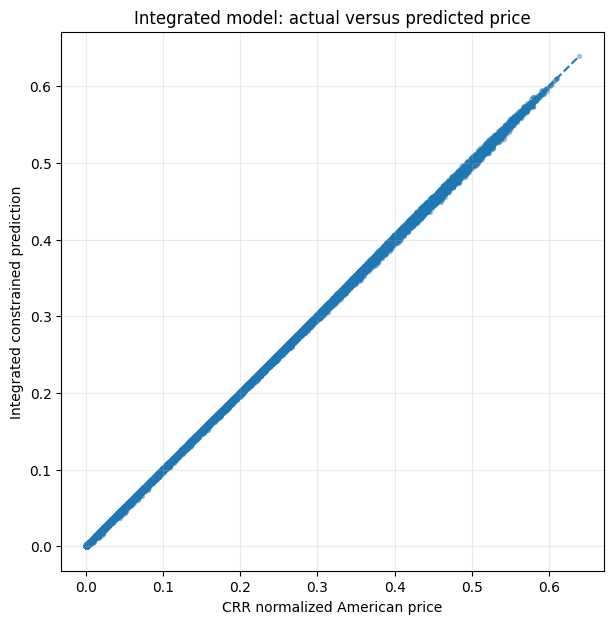

In [17]:
plt.figure(figsize=(7, 7))
plt.scatter(
    test_predictions["true_normalized_american_price"],
    test_predictions["predicted_normalized_american_price"],
    s=8,
    alpha=0.35,
)
limits = [
    min(test_predictions["true_normalized_american_price"].min(), test_predictions["predicted_normalized_american_price"].min()),
    max(test_predictions["true_normalized_american_price"].max(), test_predictions["predicted_normalized_american_price"].max()),
]
plt.plot(limits, limits, linestyle="--")
plt.xlabel("CRR normalized American price")
plt.ylabel("Integrated constrained prediction")
plt.title("Integrated model: actual versus predicted price")
plt.grid(alpha=0.25)
plt.show()

# 13. Continuation-value evaluation

Continuation value is not merely an auxiliary numerical target. It is the economic quantity against which immediate exercise is compared.

In [18]:
continuation_metrics = regression_metrics(
    test_predictions[
        "true_normalized_continuation_value"
    ],
    test_predictions[
        "predicted_normalized_continuation_value"
    ],
)

continuation_error_units = (
    (
        test_predictions[
            "predicted_normalized_continuation_value"
        ].to_numpy(dtype=float)
        - test_predictions[
            "true_normalized_continuation_value"
        ].to_numpy(dtype=float)
    )
    * test_strike
)

continuation_metrics.update(
    {
        "price_mae": float(
            np.mean(
                np.abs(
                    continuation_error_units
                )
            )
        ),
        "price_rmse": float(
            np.sqrt(
                np.mean(
                    continuation_error_units**2
                )
            )
        ),
        "maximum_price_error": float(
            np.max(
                np.abs(
                    continuation_error_units
                )
            )
        ),
    }
)

pd.Series(
    continuation_metrics,
    name="Continuation head",
)

observations             187811.000000
mae                           0.037171
rmse                          0.045228
median_absolute_error         0.037075
max_absolute_error            0.109100
mean_error                    0.004442
r2                            0.921936
within_0.001                  0.022145
within_0.005                  0.104344
within_0.01                   0.229651
within_0.05                   0.600870
price_mae                     3.717146
price_rmse                    4.522765
maximum_price_error          10.910039
Name: Continuation head, dtype: float64

# 14. Exercise classification and confusion matrix

Classification performance is evaluated independently from price error. A low pricing RMSE does not guarantee correct stopping decisions.

In [19]:
exercise_metrics = (
    binary_classification_metrics(
        test_predictions[
            "exercise_target"
        ],
        test_predictions[
            "exercise_probability"
        ],
        threshold=EXERCISE_THRESHOLD,
    )
)

exercise_confusion = (
    confusion_matrix_frame(
        test_predictions[
            "exercise_target"
        ],
        test_predictions[
            "exercise_probability"
        ],
        threshold=EXERCISE_THRESHOLD,
    )
)

pd.Series(
    exercise_metrics,
    name="Exercise head",
), exercise_confusion

(observations         187811.000000
 positive_rate             0.240454
 threshold                 0.715000
 accuracy                  0.998136
 balanced_accuracy         0.997328
 precision                 0.996477
 recall                    0.995771
 f1                        0.996124
 brier_score               0.004788
 roc_auc                   0.999976
 pr_auc                    0.999925
 Name: Exercise head, dtype: float64,
 prediction       predicted_continue  predicted_exercise
 actual                                                 
 actual_continue              142492                 159
 actual_exercise                 191               44969)

# 15. Internal consistency

The final model contains multiple routes to related financial quantities. These outputs can contradict one another even when each head performs well in isolation. The following report measures:

- direct-versus-constrained price disagreement;
- classification-versus-continuation decision disagreement;
- lower-bound violations by each price head;
- residual reconstruction identity.

In [20]:
consistency_metrics = internal_consistency_metrics(
    test_predictions,
    classification_threshold=EXERCISE_THRESHOLD,
)

consistency_flags = contradictory_output_flags(
    test_predictions,
    classification_threshold=EXERCISE_THRESHOLD,
)

consistency_flags["decision_disagreement"] = (
    (
        test_predictions["exercise_probability"].to_numpy(
            dtype=float
        )
        >= EXERCISE_THRESHOLD
    )
    != (
        test_predictions[
            "continuation_exercise_probability"
        ].to_numpy(dtype=float)
        >= CONTINUATION_THRESHOLD
    )
)

consistency_flags["any_contradiction"] = (
    consistency_flags.drop(
        columns=["any_contradiction"]
    ).any(axis=1)
)

consistency_metrics["decision_disagreement_rate"] = float(
    consistency_flags["decision_disagreement"].mean()
)

consistency_metrics["any_contradiction_rate"] = float(
    consistency_flags["any_contradiction"].mean()
)

constrained_violation_count = int(
    consistency_flags[
        [
            "constrained_negative",
            "constrained_below_european",
            "constrained_below_intrinsic",
        ]
    ]
    .any(axis=1)
    .sum()
)


# Build the economic context required by the segmented report.
test_segment_context = (
    split_frames["test"]
    .drop_duplicates(subset="sample_id")
    .set_index("sample_id")
    .copy()
)

# The production dataset stores log-moneyness rather than
# moneyness itself. Since log_moneyness = log(S / K),
# moneyness is reconstructed as exp(log_moneyness).
if "moneyness" not in test_segment_context.columns:
    if "log_moneyness" not in test_segment_context.columns:
        raise KeyError(
            "Cannot reconstruct 'moneyness': "
            "'log_moneyness' is missing. "
            "Available columns: "
            f"{test_segment_context.columns.tolist()}"
        )

    test_segment_context["moneyness"] = np.exp(
        test_segment_context["log_moneyness"].to_numpy(
            dtype=float
        )
    )

required_segment_columns = [
    "moneyness",
    "time_to_maturity",
    "volatility",
    "strike",
    "intrinsic_value",
    "continuation_value",
]

missing_segment_columns = [
    column
    for column in required_segment_columns
    if column not in test_segment_context.columns
]

if missing_segment_columns:
    raise KeyError(
        "Missing test-segment columns: "
        f"{missing_segment_columns}. "
        "Available columns: "
        f"{test_segment_context.columns.tolist()}"
    )


# Join the original economic variables back to the prediction rows.
segmented_test_analysis = test_predictions.copy()

for column in required_segment_columns:
    segmented_test_analysis[column] = (
        segmented_test_analysis["sample_id"].map(
            test_segment_context[column]
        )
    )

unmatched_segment_context = (
    segmented_test_analysis[
        required_segment_columns
    ]
    .isna()
    .sum()
)

unmatched_segment_context = unmatched_segment_context[
    unmatched_segment_context > 0
]

if not unmatched_segment_context.empty:
    raise ValueError(
        "Some test predictions could not be matched to "
        "their economic segment context:\n"
        f"{unmatched_segment_context}"
    )


segmented_results = build_integrated_segmented_report(
    segmented_test_analysis,
    exercise_threshold=EXERCISE_THRESHOLD,
    continuation_threshold=CONTINUATION_THRESHOLD,
)

static_model_comparison = build_static_model_comparison(
    premium_final_metrics_path=(
        PREMIUM_FINAL_METRICS_PATH
    ),
    multitask_final_metrics_path=(
        STEP6_FINAL_METRICS_PATH
    ),
    integrated_metrics=test_metrics,
    integrated_financial_violations=(
        constrained_violation_count
    ),
    strike=float(np.median(test_strike)),
)


display(
    pd.Series(
        consistency_metrics,
        name="Internal consistency",
    )
)

display(
    consistency_flags.mean()
    .sort_values(ascending=False)
    .rename("rate")
)

display(static_model_comparison)

observations                           1.878110e+05
direct_constrained_mae                 5.606637e-03
direct_constrained_rmse                7.508552e-03
direct_constrained_max_absolute_gap    5.177540e-02
exercise_probability_mae               2.658374e-02
exercise_probability_rmse              4.587550e-02
decision_disagreement_rate             6.613031e-03
constrained_negative_rate              0.000000e+00
constrained_below_european_rate        0.000000e+00
constrained_below_intrinsic_rate       0.000000e+00
direct_negative_rate                   0.000000e+00
direct_below_european_rate             1.618010e-01
direct_below_intrinsic_rate            2.563854e-01
any_contradiction_rate                 3.635996e-01
residual_reconstruction_mae            3.632171e-09
Name: Internal consistency, dtype: float64

any_contradiction              0.363600
direct_below_intrinsic         0.256385
direct_below_european          0.161801
decision_disagreement          0.006613
direct_negative                0.000000
constrained_below_intrinsic    0.000000
constrained_below_european     0.000000
constrained_negative           0.000000
Name: rate, dtype: float64

,pricing_role,normalized_price_mae,price_mae,exercise_f1,financial_bound_violations
model,,,,,
Notebook 04 direct MLP,specialized price,0.000782,0.078167,NaN,58810.0
Notebook 05 constrained residual,authoritative price,0.000102,0.010187,NaN,0.0
Notebook 06 exercise classifier,specialized decision,NaN,NaN,0.996393,NaN
Notebook 06 multi-task model,joint price and decision,0.000199,0.019891,0.995242,12592.0
Notebook 08 integrated model,four-head integrated,0.000423,0.042254,0.996124,0.0


The constrained head should have zero European, intrinsic, and non-negativity violations by construction. This does not guarantee monotonicity in spot, strike, volatility, or maturity; those remain empirical evaluation questions for Notebook 09.

# 16. Boundary-focused analysis

Observations are grouped by the absolute normalized difference between intrinsic and continuation value. The narrowest bands represent the most difficult optimal-stopping region.

In [21]:
test_context = (
    split_frames["test"]
    .loc[
        :,
        [
            "sample_id",
            "strike",
            "intrinsic_value",
            "continuation_value",
        ],
    ]
    .copy()
)

test_context[
    "signed_boundary_margin"
] = (
    (
        test_context[
            "intrinsic_value"
        ]
        - test_context[
            "continuation_value"
        ]
    )
    / test_context["strike"]
)
test_context[
    "boundary_distance_normalized"
] = (
    test_context[
        "signed_boundary_margin"
    ].abs()
)

test_analysis = test_context.merge(
    test_predictions,
    on="sample_id",
    validate="one_to_one",
)

boundary_analysis = (
    build_two_path_boundary_report(
        test_analysis,
        exercise_threshold=(
            EXERCISE_THRESHOLD
        ),
        continuation_threshold=(
            CONTINUATION_THRESHOLD
        ),
        bands=(0.001, 0.005, 0.010),
    )
)

boundary_analysis

,decision_path,boundary_band,boundary_limit,observations,exercise_observations,continuation_observations,threshold,normalized_price_mae,normalized_price_rmse,price_mae,...,true_positive,true_negative,false_exercise_count,missed_exercise_count,predicted_exercise_count,decision_errors,mean_regret_all,mean_regret_when_wrong,maximum_regret,total_regret
0,Exercise head,≤0.001,0.001,59673,45160,14513,0.715,0.000023,0.000086,0.002258,...,44969,14354,159,191,45128,350,0.000007,0.001129,0.025683,0.395276
1,Continuation-implied,≤0.001,0.001,59673,45160,14513,0.760,0.000023,0.000086,0.002258,...,44027,14302,211,1133,44238,1344,0.000029,0.001299,0.077979,1.745791
2,Exercise head,≤0.005,0.005,73673,45160,28513,0.715,0.000066,0.000202,0.006615,...,44969,28354,159,191,45128,350,0.000005,0.001129,0.025683,0.395276
3,Continuation-implied,≤0.005,0.005,73673,45160,28513,0.760,0.000066,0.000202,0.006615,...,44027,28302,211,1133,44238,1344,0.000024,0.001299,0.077979,1.745791
4,Exercise head,≤0.010,0.010,80785,45160,35625,0.715,0.000091,0.000273,0.009141,...,44969,35466,159,191,45128,350,0.000005,0.001129,0.025683,0.395276
5,Continuation-implied,≤0.010,0.010,80785,45160,35625,0.760,0.000091,0.000273,0.009141,...,44027,35414,211,1133,44238,1344,0.000022,0.001299,0.077979,1.745791


# 17. Optional out-of-domain evaluation

OOD evaluation uses the same scaler fitted on in-domain training data. No OOD observations are used to update the model or preprocessing.

In [22]:
ood_paths = sorted(
    DATA_DIR.glob(
        "american_put_ood_*.parquet"
    )
)

ood_results = []

for path in ood_paths:
    frame = pd.read_parquet(
        path,
        columns=RAW_COLUMNS,
    )
    if SMOKE_MODE:
        frame = frame.head(2_000).copy()

    add_integrated_targets(
        frame,
        copy=False,
    )

    dataset = IntegratedMultiHeadDataset(
        frame,
        scaler=scaler,
    )
    loader = (
        create_integrated_multihead_loader(
            dataset,
            config=loader_config,
            shuffle=False,
        )
    )

    predictions = (
        predict_integrated_multihead_model(
            selected_model,
            loader,
            device=DEVICE,
            decision_sharpness=(
                selected_loss_config
                .decision_sharpness
            ),
        )
    )

    ood_context = (
        frame.set_index("sample_id")
    )
    ood_analysis = predictions.copy()

    for column in (
        "strike",
        "intrinsic_value",
        "continuation_value",
        "normalized_european_price",
        "normalized_intrinsic_value",
    ):
        if column not in ood_analysis:
            ood_analysis[column] = (
                ood_analysis[
                    "sample_id"
                ].map(
                    ood_context[column]
                )
            )

    ood_results.append(
        summarize_integrated_ood(
            ood_analysis,
            component=path.stem,
            exercise_threshold=(
                EXERCISE_THRESHOLD
            ),
            continuation_threshold=(
                CONTINUATION_THRESHOLD
            ),
        )
    )

ood_results_frame = pd.DataFrame(
    ood_results
)

ood_specialized_comparison = (
    build_ood_specialized_comparison(
        integrated_ood=ood_results_frame,
        premium_final_metrics_path=(
            PREMIUM_FINAL_METRICS_PATH
        ),
        multitask_final_metrics_path=(
            STEP6_FINAL_METRICS_PATH
        ),
    )
)

display(ood_results_frame)
display(ood_specialized_comparison)

,component,observations,constrained_mae,constrained_rmse,constrained_median_absolute_error,constrained_max_absolute_error,constrained_mean_error,constrained_price_mae,constrained_price_rmse,direct_mae,...,continuation_path_mean_regret_when_wrong,continuation_path_maximum_regret,continuation_path_total_regret,constrained_negative_rate,constrained_below_european_rate,constrained_below_intrinsic_rate,direct_negative_rate,direct_below_european_rate,direct_below_intrinsic_rate,direct_below_financial_floor_rate
0,american_put_ood_extreme_moneyness,50000,0.000420,0.001403,0.000003,0.022790,0.000090,0.042033,0.140318,0.025658,...,0.108450,3.762533,313.311510,0.0,0.0,0.0,0.0,0.57748,0.48620,0.73970
1,american_put_ood_high_volatility,50000,0.003619,0.006261,0.001593,0.038169,0.001312,0.361919,0.626093,0.021145,...,0.003146,0.035351,0.106957,0.0,0.0,0.0,0.0,0.62666,0.00874,0.62732
2,american_put_ood_long_maturity,50000,0.007238,0.012560,0.002633,0.083259,-0.006856,0.723768,1.256032,0.017155,...,0.046569,0.142321,36.975702,0.0,0.0,0.0,0.0,0.34146,0.03664,0.37596
3,american_put_ood_rate_dividend,50000,0.002459,0.004885,0.000569,0.041489,-0.001991,0.245925,0.488515,0.008319,...,0.003103,0.058205,1.610653,0.0,0.0,0.0,0.0,0.05636,0.14684,0.18152


,notebook05_price_mae,notebook08_price_mae,notebook06_classifier_f1,notebook06_multitask_f1,notebook08_exercise_f1,notebook08_continuation_f1,notebook08_disagreement_rate
ood_set,,,,,,,
extreme_moneyness,0.000118,0.000420,0.977719,0.981491,0.963926,0.919042,0.04264
high_volatility,0.000568,0.003619,0.723926,0.772414,0.760000,0.864000,0.00100
long_maturity,0.003432,0.007238,0.641277,0.758788,0.906342,0.864505,0.00556
rate_dividend,0.002961,0.002459,0.960018,0.950167,0.981840,0.968402,0.00956


If no OOD files are displayed, the production generation pipeline has not yet been completed in the current environment. Notebook 09 must not make an OOD conclusion without those results.

# 18. Inference-speed benchmark

The integrated model performs more head computations than the earlier static models, but all heads reuse one backbone. The benchmark measures end-to-end batched inference rather than only one matrix multiplication.

In [23]:
benchmark_size = min(
    100_000,
    len(split_frames["test"]),
)

benchmark_values = scaler.transform(
    split_frames["test"]
    .iloc[:benchmark_size]
    .loc[:, FEATURE_COLUMNS]
    .to_numpy(dtype=np.float64)
).astype(np.float32)

benchmark_features = torch.from_numpy(
    benchmark_values
)

premium_benchmark_model, _ = (
    load_premium_model_package(
        PREMIUM_CHECKPOINT_PATH,
        device=DEVICE,
    )
)
classifier_benchmark_model, _ = (
    load_exercise_classifier_package(
        STEP6_CLASSIFIER_CHECKPOINT_PATH,
        STEP6_CLASSIFIER_CONFIG_PATH,
        device=DEVICE,
    )
)

runtime_rows = []
for model_name, benchmark_model in {
    "Notebook 05 constrained residual": (
        premium_benchmark_model
    ),
    "Notebook 06 exercise classifier": (
        classifier_benchmark_model
    ),
    "Notebook 08 integrated model": (
        selected_model
    ),
}.items():
    benchmark = benchmark_forward_pass(
        benchmark_model,
        benchmark_features,
        device=DEVICE,
        repeats=20,
        warmup=5,
    )
    runtime_rows.append(
        {
            "model": model_name,
            **benchmark,
            "seconds_per_observation": float(
                benchmark[
                    "median_seconds"
                ]
                / benchmark[
                    "observations"
                ]
            ),
            "device": str(DEVICE),
            "scope": "raw forward pass",
        }
    )

runtime_results = (
    pd.DataFrame(runtime_rows)
    .set_index("model")
)
runtime_summary = (
    runtime_results
    .loc[
        "Notebook 08 integrated model"
    ]
    .to_dict()
)

runtime_results

,observations,median_seconds,observations_per_second,seconds_per_observation,device,scope
model,,,,,,
Notebook 05 constrained residual,100000,0.212798,469930.111951,0.000002,cpu,raw forward pass
Notebook 06 exercise classifier,100000,0.226734,441044.578859,0.000002,cpu,raw forward pass
Notebook 08 integrated model,100000,0.452919,220790.177133,0.000005,cpu,raw forward pass


# 19. Save selected artifacts

The selected checkpoint is already saved during training. This section writes the validation ablation, test predictions, metrics, and an explicit declaration of the authoritative output.

In [24]:
validation_table.to_csv(
    ARTIFACT_DIR
    / "validation_ablation.csv"
)

pricing_comparison.reset_index().to_csv(
    ARTIFACT_DIR
    / "pricing_metrics.csv",
    index=False,
)

test_predictions.to_parquet(
    ARTIFACT_DIR
    / "test_predictions.parquet",
    index=False,
)

boundary_analysis.to_csv(
    ARTIFACT_DIR
    / "boundary_analysis.csv",
    index=False,
)

ood_results_frame.to_csv(
    ARTIFACT_DIR
    / "ood_metrics.csv",
    index=False,
)

ood_specialized_comparison.reset_index().to_csv(
    ARTIFACT_DIR
    / "ood_specialized_comparison.csv",
    index=False,
)

static_model_comparison.reset_index().to_csv(
    ARTIFACT_DIR
    / "static_model_comparison.csv",
    index=False,
)

segmented_results.to_csv(
    ARTIFACT_DIR
    / "segmented_results.csv",
    index=False,
)

runtime_results.reset_index().to_csv(
    ARTIFACT_DIR
    / "inference_benchmark.csv",
    index=False,
)

for name, history in histories.items():
    history.to_csv(
        ARTIFACT_DIR
        / f"training_history_{name}.csv",
        index=False,
    )

warm_start_history.to_csv(
    ARTIFACT_DIR
    / "training_history_warm_start.csv",
    index=False,
)

warm_start_summary.to_csv(
    ARTIFACT_DIR
    / "warm_start_summary.csv",
)

_write_export_json(
    ARTIFACT_DIR
    / "loss_config.json",
    selected_loss_config.to_dict(),
)

_write_export_json(
    ARTIFACT_DIR
    / "test_metrics.json",
    test_metrics,
)

_write_export_json(
    ARTIFACT_DIR
    / "continuation_metrics.json",
    continuation_metrics,
)

_write_export_json(
    ARTIFACT_DIR
    / "exercise_metrics.json",
    exercise_metrics,
)

_write_export_json(
    ARTIFACT_DIR
    / "consistency_metrics.json",
    consistency_metrics,
)

_write_export_json(
    ARTIFACT_DIR
    / "ood_metrics.json",
    ood_results_frame.to_dict(
        orient="records"
    ),
)

_write_export_json(
    ARTIFACT_DIR
    / "runtime_summary.json",
    runtime_summary,
)

selected_checkpoint_path = (
    scratch_checkpoint_paths[
        selected_name
    ]
)
canonical_checkpoint_path = (
    ARTIFACT_DIR
    / "best_integrated_multihead.pt"
)

if not selected_checkpoint_path.is_file():
    raise FileNotFoundError(
        "Selected scratch checkpoint is missing: "
        f"{selected_checkpoint_path}"
    )

shutil.copy2(
    selected_checkpoint_path,
    canonical_checkpoint_path,
)

selection_export = {
    **selection,
    "authoritative_price_output": (
        "constrained_price"
    ),
    "selected_source_checkpoint": (
        selected_checkpoint_path.name
    ),
    "canonical_checkpoint": (
        canonical_checkpoint_path.name
    ),
    "dependencies": (
        current_scratch_dependencies
    ),
}

_write_export_json(
    ARTIFACT_DIR
    / "selection.json",
    selection_export,
)

final_metrics = {
    "schema_version": 1,
    "status": "complete",
    "notebook": (
        "08_final_multihead_model"
    ),
    "training_profile": (
        TRAINING_PROFILE
    ),
    "selected_configuration": (
        selected_name
    ),
    "checkpoint": (
        canonical_checkpoint_path.name
    ),
    "authoritative_price_output": (
        "constrained_price"
    ),
    "thresholds": {
        "exercise_head": (
            EXERCISE_THRESHOLD
        ),
        "continuation_path": (
            CONTINUATION_THRESHOLD
        ),
    },
    "selection": selection_export,
    "pricing": (
        pricing_comparison
        .reset_index()
        .to_dict(orient="records")
    ),
    "continuation": (
        continuation_metrics
    ),
    "classification": (
        exercise_metrics
    ),
    "consistency": (
        consistency_metrics
    ),
    "boundary": (
        boundary_analysis
        .to_dict(orient="records")
    ),
    "ood": (
        ood_results_frame
        .to_dict(orient="records")
    ),
    "ood_specialized_comparison": (
        ood_specialized_comparison
        .reset_index()
        .to_dict(orient="records")
    ),
    "static_model_comparison": (
        static_model_comparison
        .reset_index()
        .to_dict(orient="records")
    ),
    "segmented_results": (
        segmented_results
        .to_dict(orient="records")
    ),
    "warm_start": (
        warm_start_summary.to_dict()
    ),
    "runtime": (
        runtime_results
        .reset_index()
        .to_dict(orient="records")
    ),
    "dependencies": (
        current_scratch_dependencies
    ),
}

_write_export_json(
    ARTIFACT_DIR
    / "final_metrics.json",
    final_metrics,
)

sorted(
    path.name
    for path in ARTIFACT_DIR.iterdir()
)

['best_balanced.pt',
 'best_decision_focused.pt',
 'best_integrated_multihead.pt',
 'best_pricing_focused.pt',
 'best_warm_start.pt',
 'boundary_analysis.csv',
 'consistency_metrics.json',
 'continuation_metrics.json',
 'exercise_metrics.json',
 'feature_scaler.joblib',
 'final_metrics.json',
 'inference_benchmark.csv',
 'loss_config.json',
 'ood_metrics.csv',
 'ood_metrics.json',
 'ood_specialized_comparison.csv',
 'pricing_metrics.csv',
 'runtime_summary.json',
 'scratch_training_complete.json',
 'scratch_training_config.json',
 'segmented_results.csv',
 'selection.json',
 'static_model_comparison.csv',
 'test_metrics.json',
 'test_predictions.parquet',
 'training_history_balanced.csv',
 'training_history_decision_focused.csv',
 'training_history_pricing_focused.csv',
 'training_history_warm_start.csv',
 'validation_ablation.csv',
 'warm_start_summary.csv',
 'warm_start_training_complete.json']

# 20. Interpretation framework

The final model should not be declared superior simply because it is more complex. The evidence must distinguish among several possible outcomes:

- **Joint-learning benefit:** constrained price, continuation, and boundary metrics improve together.
- **Pricing-only benefit:** price improves while continuation or exercise performance deteriorates.
- **Decision-only benefit:** stopping decisions improve without material pricing improvement.
- **Internal-coherence benefit:** predictive metrics remain similar but contradictory outputs decline.
- **Negative result:** the additional heads do not justify their parameter and training cost.

A negative or mixed result remains academically useful because the separately trained models provide controlled ablations.

# 21. Relationship with Neural Longstaff–Schwartz

The integrated model and neural LSM solve related but distinct problems:

| Model family | Input | Learning problem | Primary output |
|---|---|---|---|
| Integrated static model | One contract parameter vector | Supervised approximation of CRR labels | Fast price and root exercise diagnostics |
| Neural LSM | Simulated path states over exercise dates | Backward-induction continuation policy | Path-dependent stopping policy and Monte Carlo price |

They are therefore compared in Notebook 09 rather than combined into one architecture.

# 22. Limitations

- The four heads share the same synthetic CRR labels and are not independent sources of truth.
- Continuation values are root-node quantities produced by the selected finite tree.
- Consistency losses can encourage agreement even when both heads are wrong.
- Hard lower-bound reconstruction does not enforce all no-arbitrage shape conditions.
- Loss weights remain design choices, even though the candidate set is predefined.
- Warm-start and scratch architectures differ in capacity unless an explicitly matched architecture is used.
- Strong in-domain performance does not establish reliable OOD behavior or real-market validity.

# 23. References used in this notebook

Caruana, R. (1997). Multitask learning. *Machine Learning, 28*, 41–75.

Ding, L., Lu, E., & Cheung, K. (2025). *Deep learning option pricing with market implied volatility surfaces*. arXiv:2509.05911.

Ke, A., & Yang, A. (2019). *Option pricing with deep learning*. CS230, Stanford University.

Longstaff, F. A., & Schwartz, E. S. (2001). Valuing American options by simulation: A simple least-squares approach. *Review of Financial Studies, 14*(1), 113–147.

Pimentel, R., et al. (2026). Option pricing with deep learning: A long short-term memory approach. *Decisions in Economics and Finance, 49*, 155–186.

Pu, V. R. H. (2021). *Pricing options using deep neural networks from a practical perspective* [Master’s thesis, Imperial College London].

# 24. Development checkpoint

Notebook 08 produces the final integrated static model and its complete analytical outputs. Notebook 09 will:

1. load all final checkpoints and result artifacts;
2. compare static, CRR, classical LSM, and neural LSM methods on aligned evaluation sets;
3. decide H1–H6;
4. complete the literature synthesis;
5. write the final discussion, limitations, and conclusion.